In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import re
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import random
import csv
from matplotlib.colors import to_rgb

In [3]:
# Read in data
cd8_t = pd.read_csv('../data/cd8_t_cells_cd8_low_removed_umap_patient_updated.csv', index_col = 0)
cd8_t.head()

,209Bi_CD45,Center,164Dy,166Er_CD34,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,104Pd_CD45,...,171Yb_Granzyme_B_asinh_coarseAlign_fineAlign,172Yb_CD38_asinh_coarseAlign_fineAlign,173Yb_CD14_asinh_coarseAlign_fineAlign,174Yb_HLA-DR_asinh_coarseAlign_fineAlign,176Yb_CD56_asinh_coarseAlign_fineAlign,Alignment_MC_fineAlign,FlowSOM_cluster,FlowSOM_metacluster,UMAP_X,UMAP_Y
1,0.463586,508.199,0.0,1.45153,13,0.0,0.0,125.4630,252.016,0.000000,...,0.126867,2.189834,0.122775,0.347940,0.044064,5,144,35,-1.817426,7.321785
2,2.486070,0.000,0.0,0.00000,18,0.0,0.0,121.0320,252.836,0.000000,...,0.975536,1.903271,0.006609,0.504978,4.161595,5,57,18,4.705129,3.655561
3,0.000000,0.000,0.0,7.91201,16,0.0,0.0,82.7162,192.006,0.000000,...,5.615166,1.859332,0.014530,0.073580,0.054384,7,70,22,-2.416794,-2.556074
4,5.091210,582.354,0.0,0.00000,14,0.0,0.0,199.5410,317.372,0.000000,...,6.025747,1.367487,0.014530,0.073580,3.197923,7,49,15,1.031044,-5.505780
5,0.896022,419.084,0.0,0.00000,13,0.0,0.0,164.2140,389.681,0.692141,...,3.764776,1.084292,0.014530,0.073580,2.563063,7,44,12,2.328280,-1.976762


In [5]:
# Delete spare progression sample (there was a second later measurement which was associated with progression)
# Delete sample 61290 006 as the patient went off trial due to participant preference
print(cd8_t.shape)
cd8_t = cd8_t.loc[cd8_t['FileName'] != 'P02_SPD_T_Cell_Panel',:]
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P26'),:]
cd8_t['FileName'] = cd8_t['FileName'].str.replace('P02_SPD_2_T_Cell_Panel', 'P02_SPD_T_Cell_Panel')
cd8_t['Timepoint'] = cd8_t['Timepoint'].str.replace('SPD_2', 'SPD')
cd8_t['Patient_ID'] = cd8_t['Patient_ID'].str.replace('P02_2', 'P02')

# Delete the following samples as they have only a single measurement
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P27'),:]
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P15'),:]
print(cd8_t.shape)

(56050, 68)
(53675, 68)


In [7]:
# Delete the spare columns called '7 month response' and '12 month response'. I will then add
# some clinical information which Julie recently gave me
print(cd8_t.shape)
cd8_t = cd8_t.drop(['7_month_response', '12_month_response'], axis = 1)
print(cd8_t.shape)

(53675, 68)
(53675, 66)


In [11]:
# Read in annotations and map them to the cell type
annotations = pd.read_excel('../data/2024_06_25_Annotations.xlsx')
annotations['Annotation'].value_counts()

annotation_dict = dict(zip(annotations['FlowSOM_Cluster'], annotations['Annotation']))
annotation_dict
cd8_t['cell_type'] = cd8_t['FlowSOM_metacluster'].map(annotation_dict)
cd8_t['cell_type'].unique()

array(['Naïve/Memory', 'CD56pos_CD127pos_Trm', 'CD56neg_GzmBpos',
       'CD56pos_GzmBpos', 'CD56neg_CD127pos_Trm', 'CD56neg_CD127neg_Trm',
       'CD56pos_CD127neg_Trm', 'Memory', 'Activated'], dtype=object)

In [13]:
# Read in color palette
color = pd.read_excel('../data/2025_12_15_Cell_color_table.xlsx')
cell_type_color_dict = dict(zip(color['Cell_type'], color['Color']))
cell_type_color_dict


{'Naïve/Memory': '#F1C40FFF',
 'Memory': '#2ECC71FF',
 'Activated': '#F39C12FF',
 'CD56neg_CD127pos_Trm': '#E74C3CFF',
 'CD56neg_CD127neg_Trm': '#34495EFF',
 'CD56pos_CD127pos_Trm': '#9B59B6FF',
 'CD56pos_CD127neg_Trm': '#1ABC9CFF',
 'CD56neg_GzmBpos': '#3498DBFF',
 'CD56pos_GzmBpos': '#D35400FF'}

In [15]:
# Create a function which changes the font of negative sign so that it is smaller in each figure
def custom_formatter(x, pos):
    s = '{:.0f}'.format(x)
    return s.replace('-', '\u002D') 

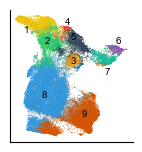

In [19]:
# Make a UMAP with all the cell types
plt.rcParams["font.family"] = "Arial"
plt.rcParams.update({'mathtext.default':  'regular' })

# Set font to be arial and an editable text type
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text


fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize  = (6.1/4, 3.25/2))
                       
ax.scatter(x = cd8_t['UMAP_X'], y = cd8_t['UMAP_Y'], c = cd8_t['cell_type'].map(cell_type_color_dict), 
          s = 0.25, lw = 0, rasterized=True)

# Create a dictionary which specifies the location of each text position
text_positions = { '1': (-3, 6), '6': (5, 4.5),
    '8': (-1.5, -2.5), '9': (2, -5),
    '4': (0.5, 7), '5': (1, 5),
    '7': (4, 0.5), '2': (-1.25, 4.5), '3': (1, 2)}

# Use a for loop to add the text to the desired position of the UMAP
for label, (x, y) in text_positions.items():
    ax.text(x=x, y=y, s=label, fontsize=7)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('', fontsize = 7)
ax.set_ylabel('', fontsize = 7)
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(axis = 'both', labelsize = 7, pad = 1, length = 1.5)

plt.tight_layout()
#fig.savefig('../results/cell_type_umap_v2.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)